# The Determinant as Area

**This notebook teaches the determinant from scratch — it assumes only that a matrix can move points around.**

The determinant is usually introduced as a formula to memorize, $ad - bc$, with no hint of where it comes from. It has a picture. Take the two columns of a matrix as two arrows; they span a parallelogram; **the determinant is that parallelogram's area**. When the area hits zero, space has been flattened onto a line — and that is exactly when the matrix is *singular* and its columns are *dependent*. This notebook makes the collapse visible.

## Learning objectives

- Interpret the $2\times2$ determinant as the **signed area** of the transformed unit square.
- Connect $\det = 0$ to **singularity** and to **linear dependence**.
- Relate the determinant to the dot product as the perpendicular counterpart of $\cos\theta$.

## Background

For $A = \begin{bmatrix}a & b\\ c & d\end{bmatrix}$ the determinant is

$$\det A = ad - bc.$$

The two **columns** of $A$ are two vectors, $\begin{bmatrix}a\\c\end{bmatrix}$ and $\begin{bmatrix}b\\d\end{bmatrix}$; laid head-to-tail they span a parallelogram, and $\det A$ is its signed area. Since the columns are where $\hat{\imath}$ and $\hat{\jmath}$ land, this is the same as saying: **$\det A$ is the area of the image of the unit square**, i.e. the factor by which $A$ scales area.

It pairs with the dot product. For two vectors separated by angle $\theta$,

$$\mathbf{u}\cdot\mathbf{v} = \lVert\mathbf{u}\rVert\lVert\mathbf{v}\rVert\cos\theta, \qquad \det\!\begin{bmatrix}\mathbf{u} & \mathbf{v}\end{bmatrix} = \lVert\mathbf{u}\rVert\lVert\mathbf{v}\rVert\sin\theta.$$

The dot product measures how **parallel** two vectors are; the determinant measures how **perpendicular** they are. So $\det = 0$ means $\sin\theta = 0$, i.e. the two columns point along the same line — they are **linearly dependent**.

## This notebook covers

1. The unit square and its image; the shaded area is $|\det|$.
2. Sweeping a column toward dependence; area and $\det$ going to zero together.
3. The sign of the determinant: orientation flip.
4. $\det = 0 \Rightarrow$ singular $\Rightarrow$ dependent columns, checked three ways.

**Prerequisites:** `U2-4_Transformations-1_MatrixAsMap`

**Dataset:** none — matrices are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plotting helper: label the axis ends compactly (for grids of small panels)
def label_axes(ax, x='x', y='y', size=8):
    ax.set_xlabel(x, loc='right', fontsize=size)
    ax.set_ylabel(y, loc='top', rotation=0, fontsize=size)
# plotting helper: draw one vector as an arrow starting at `tail`
# (zorder keeps arrows on top of the axis spines, which are the same white)
def arrow(ax, tail, vec, color, label=None, alpha=1.0):
    ax.quiver(tail[0], tail[1], vec[0], vec[1], angles='xy', scale_units='xy',
              scale=1, color=color, label=label, alpha=alpha, width=0.011, zorder=5)

# plotting helper: shade the parallelogram spanned by the two columns of A
def draw_parallelogram(ax, A, color="gray", alpha=0.35):
    o, c1, c2 = np.zeros(2), A[:, 0], A[:, 1]
    corners = np.array([o, c1, c1 + c2, c2, o]).T
    ax.fill(corners[0], corners[1], color=color, alpha=alpha)
    ax.plot(corners[0], corners[1], color=color, lw=1)

## 1. The unit square becomes a parallelogram

Start with the **unit square** — corners $(0,0), (1,0), (1,1), (0,1)$ — whose area is exactly 1. Apply $A$ to all four corners. Because the columns of $A$ are the images of $\hat{\imath}$ and $\hat{\jmath}$, the square becomes the parallelogram those two columns span.

Its area is $|\det A|$. Since the square started with area 1, **the determinant is the factor by which $A$ scales area**.

In [2]:
A = np.array([[3.0, 1.0],
              [1.0, 2.0]])
helpers.show(A, name="A")

square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]], dtype=float)      # unit square, as columns

print(f"det(A) by the formula ad - bc = {A[0,0]*A[1,1] - A[0,1]*A[1,0]:.1f}")
print(f"det(A) from numpy       = {np.linalg.det(A):.1f}")

<IPython.core.display.Math object>

det(A) by the formula ad - bc = 5.0
det(A) from numpy       = 5.0


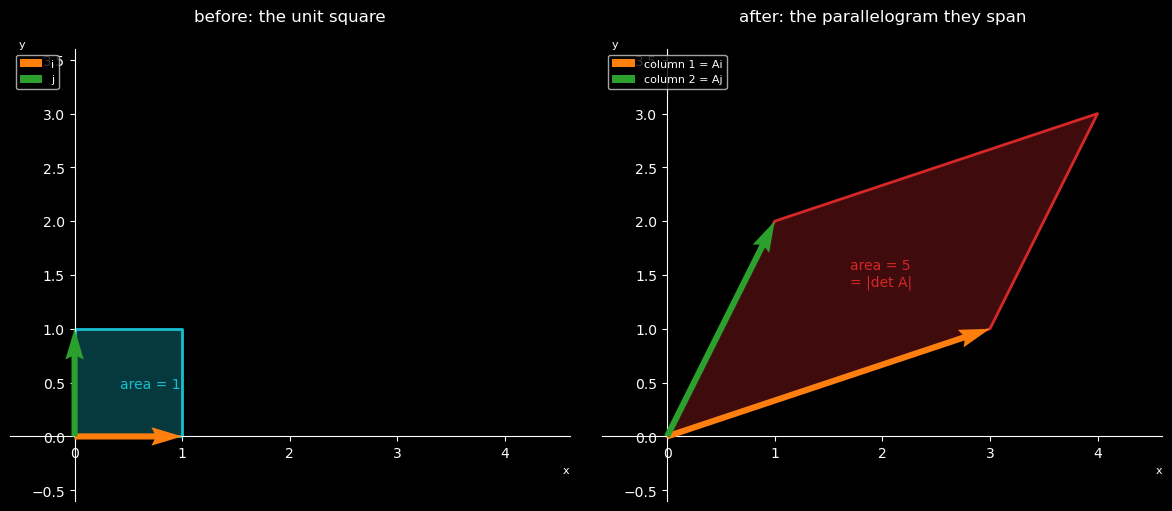

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.fill(square[0], square[1], color="tab:cyan", alpha=0.3)
ax.plot(square[0], square[1], color="tab:cyan", lw=2)
arrow(ax, (0, 0), [1, 0], "tab:orange", "i")
arrow(ax, (0, 0), [0, 1], "tab:green", "j")
ax.text(0.42, 0.45, "area = 1", color="tab:cyan", fontsize=10)
ax.set_title("before: the unit square", pad=20)

ax = axes[1]
moved = A @ square
ax.fill(moved[0], moved[1], color="tab:red", alpha=0.3)
ax.plot(moved[0], moved[1], color="tab:red", lw=2)
arrow(ax, (0, 0), A[:, 0], "tab:orange", "column 1 = Ai")
arrow(ax, (0, 0), A[:, 1], "tab:green", "column 2 = Aj")
ax.text(1.7, 1.4, f"area = {abs(np.linalg.det(A)):.0f}\n= |det A|", color="tab:red", fontsize=10)
ax.set_title("after: the parallelogram they span", pad=20)

for ax in axes:
    center_axes(ax); label_axes(ax)
    ax.set_xlim(-0.6, 4.6); ax.set_ylim(-0.6, 3.6); ax.set_aspect("equal")
    ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 2. Driving the area to zero

Now watch what happens as the two columns swing toward each other. Hold the first column fixed at $\begin{bmatrix}2\\0\end{bmatrix}$ and let the second sweep from straight up ($\theta = 90°$) down toward the first ($\theta = 0°$):

$$A(\theta) = \begin{bmatrix}2 & \cos\theta\\ 0 & \sin\theta\end{bmatrix}, \qquad \det A(\theta) = 2\sin\theta$$

As $\theta \to 0$ the parallelogram flattens and its area drains away — and the formula agrees, because $\det = \lVert\mathbf{u}\rVert\lVert\mathbf{v}\rVert\sin\theta$ and $\sin 0 = 0$.

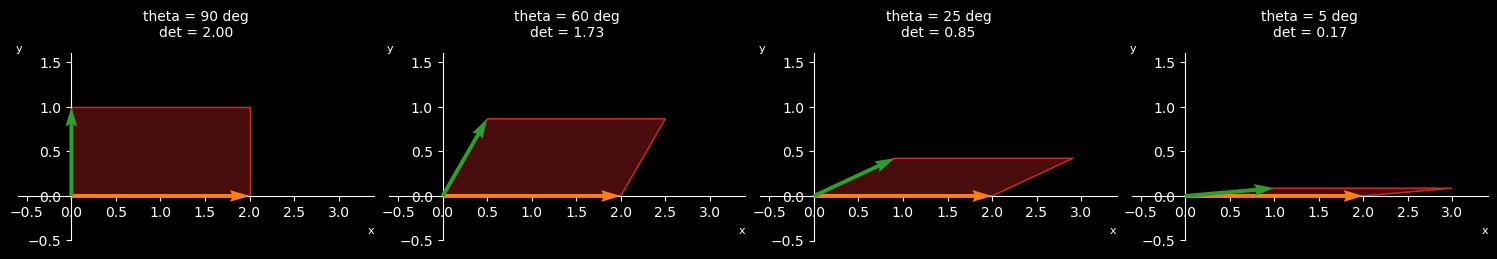

In [4]:
def A_theta(deg):
    t = np.radians(deg)
    return np.array([[2.0, np.cos(t)],
                     [0.0, np.sin(t)]])

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, deg in zip(axes, [90, 60, 25, 5]):
    M = A_theta(deg)
    draw_parallelogram(ax, M, color="tab:red")
    arrow(ax, (0, 0), M[:, 0], "tab:orange")
    arrow(ax, (0, 0), M[:, 1], "tab:green")
    center_axes(ax); label_axes(ax)
    ax.set_xlim(-0.6, 3.4); ax.set_ylim(-0.5, 1.6); ax.set_aspect("equal")
    ax.set_title(f"theta = {deg} deg\ndet = {np.linalg.det(M):.2f}", pad=12, fontsize=10)
plt.tight_layout()
plt.show()

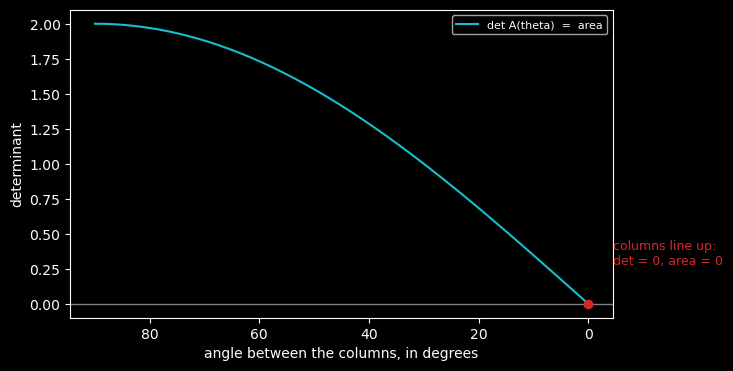

In [5]:
# the same sweep as a curve: area and det fall together, hitting 0 when the columns line up
degs = np.linspace(90, 0, 181)
dets = np.array([np.linalg.det(A_theta(d)) for d in degs])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(degs, dets, color="tab:cyan", label="det A(theta)  =  area")
ax.axhline(0, color="gray", lw=1)
ax.plot(0, 0, "o", color="tab:red")
ax.annotate("columns line up:\ndet = 0, area = 0", (0, 0), textcoords="offset points",
            xytext=(18, 28), color="tab:red", fontsize=9)
ax.set_xlabel("angle between the columns, in degrees")
ax.set_ylabel("determinant")
ax.invert_xaxis()
ax.legend(fontsize=8)
plt.show()

## 3. The sign: which way round?

The determinant is a **signed** area. Swap the two columns and the parallelogram is the same shape, same area — but the determinant flips sign.

The sign records **orientation**: whether the transformation preserved the handedness of space or mirrored it. A negative determinant means the shape was flipped over, as by a reflection. When only size matters, use $|\det A|$.

In [6]:
A_swapped = A[:, ::-1]          # same two columns, opposite order
helpers.show(A, name="A")
helpers.show(A_swapped, label="columns swapped")
print(f"det(A)         = {np.linalg.det(A):+.1f}")
print(f"det(A swapped) = {np.linalg.det(A_swapped):+.1f}   <- same size, opposite sign")

reflection = np.array([[-1.0, 0.0], [0.0, 1.0]])
print(f"det(reflection across the y-axis) = {np.linalg.det(reflection):+.1f}   <- flips orientation")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

det(A)         = +5.0
det(A swapped) = -5.0   <- same size, opposite sign
det(reflection across the y-axis) = -1.0   <- flips orientation


## 4. $\det = 0$, three ways of saying one thing

When the determinant is zero, three statements become true at once. They sound different but describe the same collapse:

1. **Geometric** — the image has zero area: the whole plane is squashed onto a line.
2. **Algebraic** — the columns are **linearly dependent**: one is a multiple of the other.
3. **Practical** — the matrix is **singular**: it has no inverse, and $A\mathbf{x} = \mathbf{b}$ has no unique solution.

The third is the one that matters for solving systems, and it's the subject of the next notebook. Below we take a matrix with $\det = 0$ and confirm all three.

In [7]:
B = np.array([[1.0, 2.0],
              [2.0, 4.0]])          # column 2 = 2 x column 1
helpers.show(B, name="B")
print(f"1. det(B) = {np.linalg.det(B):.1f}  -> zero area")
print(f"2. column 2 / column 1 = {B[:, 1] / B[:, 0]}  -> a constant, so the columns are dependent")

try:
    np.linalg.inv(B)
except np.linalg.LinAlgError as e:
    print(f"3. np.linalg.inv(B) raises LinAlgError: {e}  -> singular")

<IPython.core.display.Math object>

1. det(B) = 0.0  -> zero area
2. column 2 / column 1 = [2. 2.]  -> a constant, so the columns are dependent
3. np.linalg.inv(B) raises LinAlgError: Singular matrix  -> singular


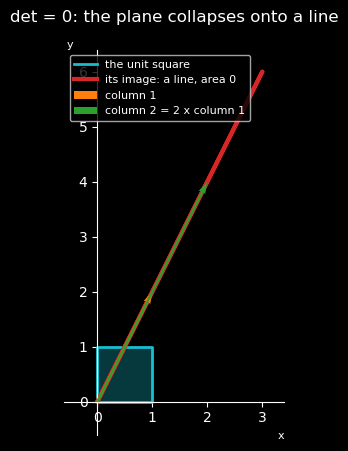

In [8]:
# the collapse, drawn: every point of the shape lands on a single line
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.fill(square[0], square[1], color="tab:cyan", alpha=0.3)
ax.plot(square[0], square[1], color="tab:cyan", lw=2, label="the unit square")

flat = B @ square
ax.plot(flat[0], flat[1], color="tab:red", lw=3, label="its image: a line, area 0")
arrow(ax, (0, 0), B[:, 0], "tab:orange", "column 1")
arrow(ax, (0, 0), B[:, 1], "tab:green", "column 2 = 2 x column 1")

center_axes(ax); label_axes(ax)
ax.set_xlim(-0.6, 3.4); ax.set_ylim(-0.6, 6.4); ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
ax.set_title("det = 0: the plane collapses onto a line", pad=20)
plt.show()

## 5. Summary

- $\det A = ad - bc$ is the **signed area** of the parallelogram spanned by $A$'s columns — equivalently, the factor by which $A$ scales area.
- It is the perpendicular counterpart of the dot product: $\mathbf{u}\cdot\mathbf{v} = \lVert u\rVert\lVert v\rVert\cos\theta$ versus $\det = \lVert u\rVert\lVert v\rVert\sin\theta$.
- The **sign** records orientation; a reflection has a negative determinant.
- **$\det = 0$** means the plane collapses to a line, the columns are **dependent**, and the matrix is **singular**.

Next: what "singular" costs you — the inverse, and why $\det = 0$ means it doesn't exist (`U2-5_Determinants-2_InverseAsUndo`).